importing the required libraries

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

loading the data

In [18]:
df = pd.read_csv("../data/train.csv")
df_t = pd.read_csv("../data/test.csv")

data inspection

In [19]:
df.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  object 
 9   City_Type                    668665 non-null  object 
 10  Current_Car_Type             668665 non-null  object 
 11  Home_Charging_Possible       668665 non-null  object 
 12  Subsidy_Available            668665 non-null  object 
 13 

In [21]:
cat_cols = df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(exclude=['object']).columns

In [36]:
cat_cols = cat_cols.drop("Will_Buy_EV")
target_col = df["Will_Buy_EV"]

univariate analysis

In [29]:
df.describe()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level
count,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000
mean,334332.000000,47.039171,84769.266989,32.158298,1.712626,4.960408,7.176314,2.935477
std,193027.103211,12.875448,28648.029042,18.730474,0.729275,3.926843,5.186627,1.429119
min,0.000000,25.000000,30000.000000,5.000000,1.000000,0.000000,0.000000,1.000000
25%,167166.000000,36.000000,67376.000000,17.200000,1.000000,2.000000,3.000000,2.000000
50%,334332.000000,47.000000,84880.000000,33.600000,2.000000,4.000000,6.000000,3.000000
75%,501498.000000,58.000000,102753.000000,47.400000,2.000000,7.000000,10.000000,4.000000
max,668664.000000,69.000000,188549.000000,98.700000,4.000000,14.000000,19.000000,5.000000


In [30]:
target_counts = target_col.value_counts().sort_index()
target_counts

Will_Buy_EV
No     551886
Yes    116779
Name: count, dtype: int64

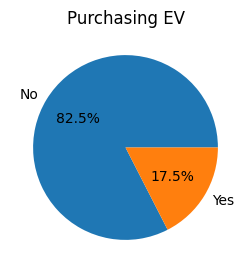

In [33]:
plt.figure(figsize=(6, 3))

plt.pie(target_counts.values, labels=['No', 'Yes'], autopct='%1.1f%%')

plt.title('Purchasing EV')
plt.show()

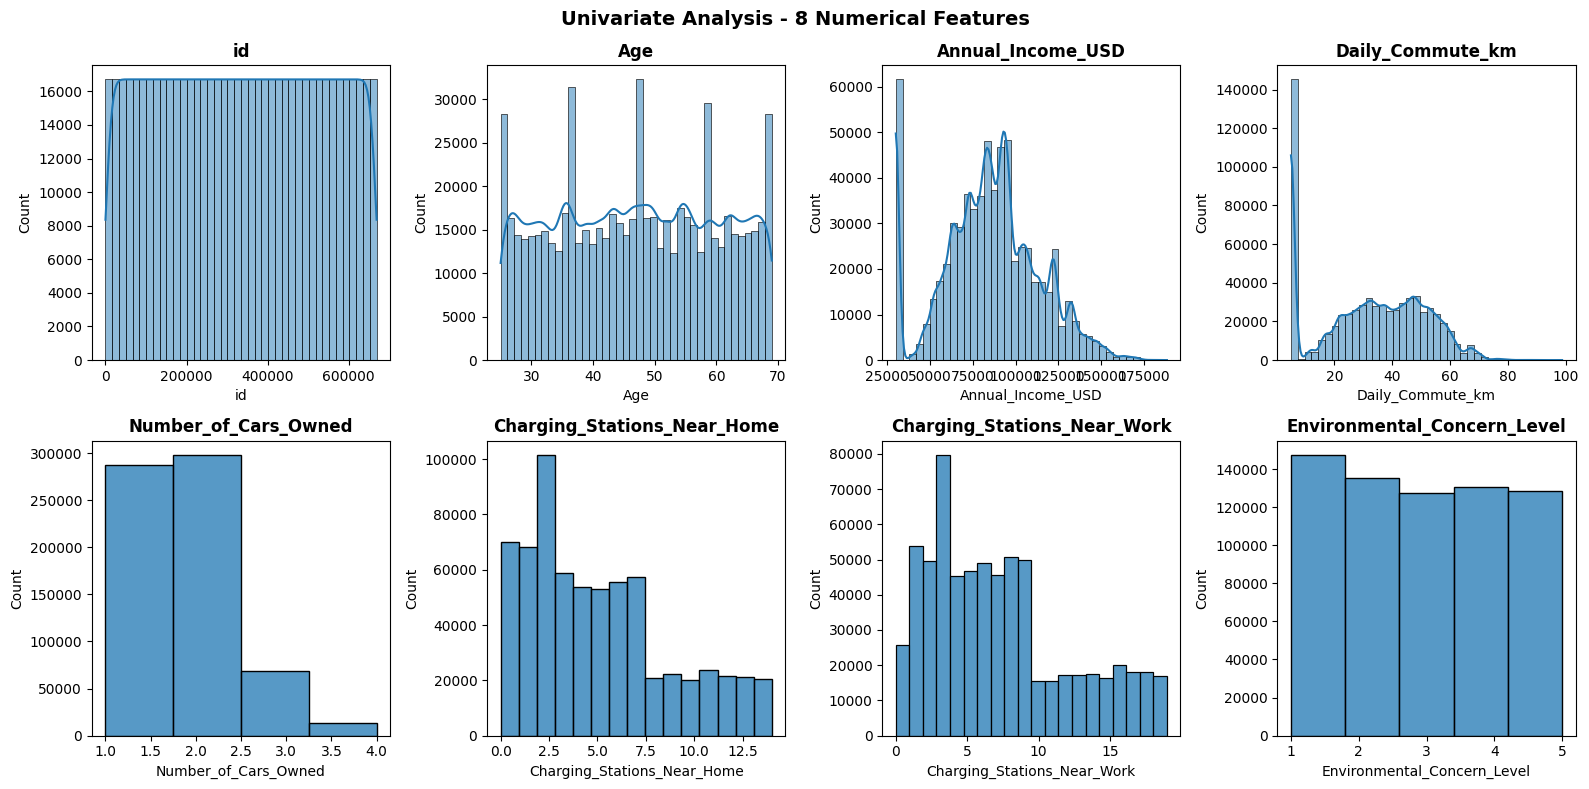

In [45]:
n_cols = 4
n_rows = (len(num_cols) + n_cols - 1) // n_cols  
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()
fig.suptitle(f'Univariate Analysis - {len(num_cols)} Numerical Features', fontweight='bold', fontsize=14)

for idx, col in enumerate(num_cols):
    ax = axes[idx]
    # Check if continuous or discrete
    n_unique = df[col].nunique()
    if n_unique > 20:  # Continuous - use KDE
        sns.histplot(data=df, x=col, kde=True, ax=ax, bins=40)
    else:  # Discrete - no KDE
        sns.histplot(data=df, x=col, ax=ax, bins=min(n_unique, 20))
    
    ax.set_title(f'{col}', fontweight='bold')

# Hide remaining empty subplots
for idx in range(len(num_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [40]:
from scipy.stats import skew
for col in num_cols:
    skewness = df[col].skew()
    if skewness > 0.5:
        print(f"{col} is right skewed with skewness: {skewness}")
    elif skewness < -0.5:
        print(f"{col} is left skewed with skewness: {skewness}")

Number_of_Cars_Owned is right skewed with skewness: 0.8144971707345123
Charging_Stations_Near_Home is right skewed with skewness: 0.6987301218816998
Charging_Stations_Near_Work is right skewed with skewness: 0.7001875067778817


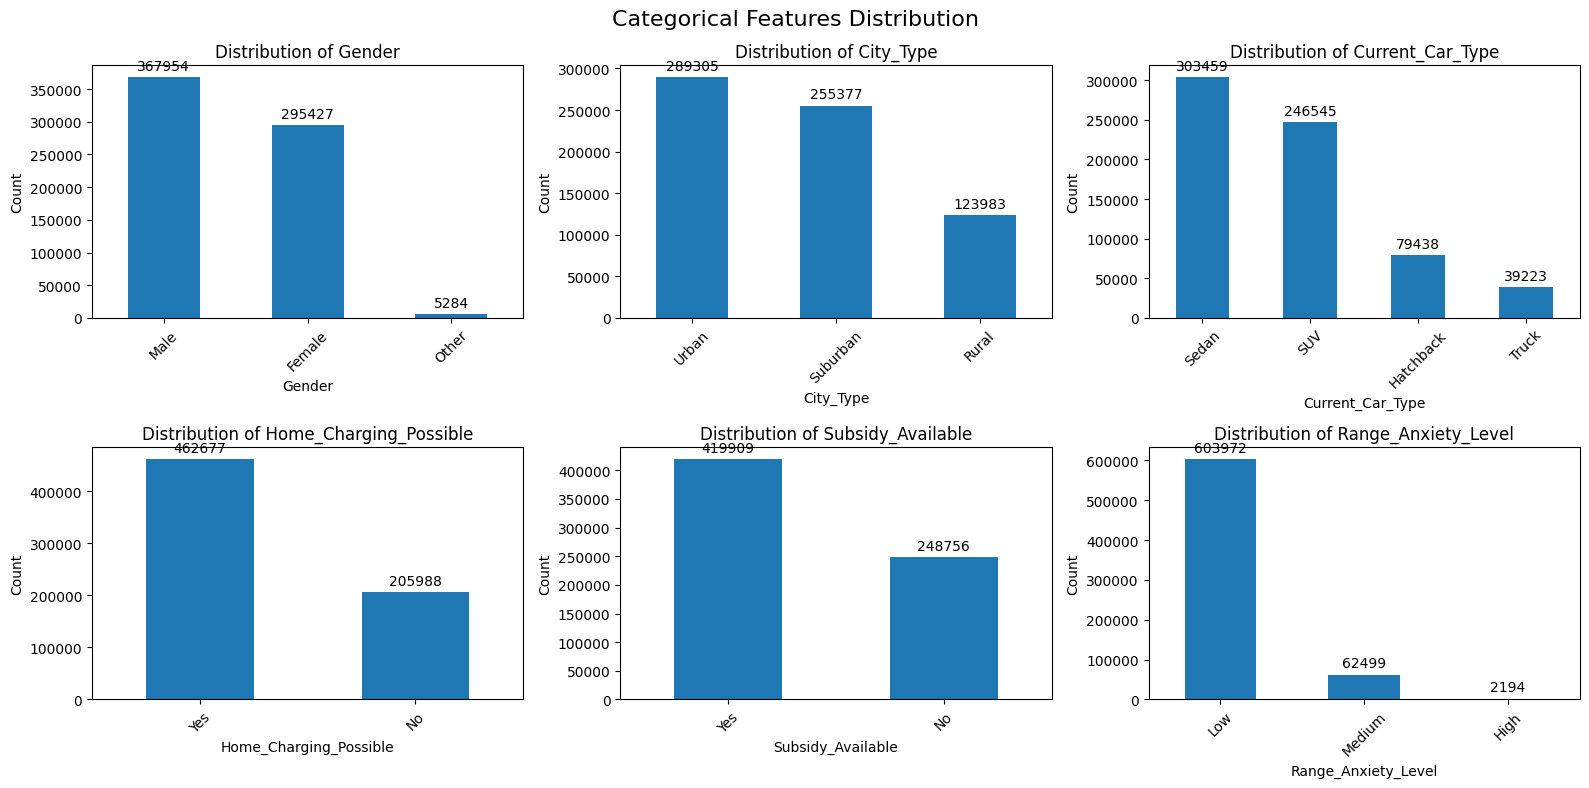

In [44]:
n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()
fig.suptitle('Categorical Features Distribution', fontsize=16)

for i, col in enumerate(cat_cols):
    ax = axes[i]
    df[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    for container in ax.containers:
        ax.bar_label(container, padding=3)

# Hide unused subplots
for i in range(len(cat_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

Key Findings:
1. the data is imbalanced

evaluation metrics - area under ROC